<h3>Import Library
<hr>

In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split 
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from gensim.models import Word2Vec
from googletrans import Translator

import time
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.corpus import sentiwordnet as swn
from nltk import pos_tag
from nltk.stem import SnowballStemmer, WordNetLemmatizer
import nltk

nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('sentiwordnet')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Nugraha Adani\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to C:\Users\Nugraha
[nltk_data]     Adani\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Nugraha
[nltk_data]     Adani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package sentiwordnet to C:\Users\Nugraha
[nltk_data]     Adani\AppData\Roaming\nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!


True

<h2>Loading data
<hr>  

In [10]:
df = pd.read_csv('scraping_pjv_last.csv')
df

C:\Users\Nugraha Adani\AppData\Local\Temp\ipykernel_8612\1305979500.py:1: DtypeWarning: Columns (0: textTranslated, 1: translatedLanguage) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('scraping_pjv_last.csv')


,searchString,reviewerId,reviewerUrl,name,reviewerNumberOfReviews,isLocalGuide,reviewerPhotoUrl,text,textTranslated,publishAt,...,temporarilyClosed,reviewsCount,url,price,cid,fid,imageUrl,scrapedAt,language,kgmid
0,Direct Detail URL: https://www.google.com/maps...,116138893283831805240,https://www.google.com/maps/contrib/1161388932...,Heru Nurjaya,1,False,https://lh3.googleusercontent.com/a/ACg8ocIgVV...,NaN,NaN,34 minutes ago,...,False,95263,https://www.google.com/maps/search/?api=1&quer...,NaN,12704771329685459122,0x2e68e6603f408a09:0xb0506a362a7810b2,https://lh3.googleusercontent.com/gps-cs-s/APN...,2026-04-12T08:06:29.295Z,en,/g/122_9h8y
1,Direct Detail URL: https://www.google.com/maps...,111438741580280930071,https://www.google.com/maps/contrib/1114387415...,Vera Rusli,4,False,https://lh3.googleusercontent.com/a-/ALV-UjWw5...,NaN,NaN,3 hours ago,...,False,95263,https://www.google.com/maps/search/?api=1&quer...,NaN,12704771329685459122,0x2e68e6603f408a09:0xb0506a362a7810b2,https://lh3.googleusercontent.com/gps-cs-s/APN...,2026-04-12T08:06:29.295Z,en,/g/122_9h8y
2,Direct Detail URL: https://www.google.com/maps...,115770749596150124472,https://www.google.com/maps/contrib/1157707495...,arum_fika,1,False,https://lh3.googleusercontent.com/a/ACg8ocITZm...,Manajemen tolong diperbaiki atapnya dong...huj...,"Management, please fix the roof...it's leaking...",3 hours ago,...,False,95263,https://www.google.com/maps/search/?api=1&quer...,NaN,12704771329685459122,0x2e68e6603f408a09:0xb0506a362a7810b2,https://lh3.googleusercontent.com/gps-cs-s/APN...,2026-04-12T08:06:29.295Z,en,/g/122_9h8y
3,Direct Detail URL: https://www.google.com/maps...,110256955594411733360,https://www.google.com/maps/contrib/1102569555...,Hary Kurnia,2,True,https://lh3.googleusercontent.com/a/ACg8ocIQ9B...,Keren,Cool,4 hours ago,...,False,95263,https://www.google.com/maps/search/?api=1&quer...,NaN,12704771329685459122,0x2e68e6603f408a09:0xb0506a362a7810b2,https://lh3.googleusercontent.com/gps-cs-s/APN...,2026-04-12T08:06:29.295Z,en,/g/122_9h8y
4,Direct Detail URL: https://www.google.com/maps...,107617757944488243529,https://www.google.com/maps/contrib/1076177579...,Salsa Gustina,1,False,https://lh3.googleusercontent.com/a/ACg8ocIqBv...,Pelayanan parkirnya jelek ach,"The parking service is bad, ach",6 hours ago,...,False,95263,https://www.google.com/maps/search/?api=1&quer...,NaN,12704771329685459122,0x2e68e6603f408a09:0xb0506a362a7810b2,https://lh3.googleusercontent.com/gps-cs-s/APN...,2026-04-12T08:06:29.295Z,en,/g/122_9h8y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16661,Direct Detail URL: https://www.google.com/maps...,114891828389725646483,https://www.google.com/maps/contrib/1148918283...,Deavan AutoSalon Deavan,16,True,https://lh3.googleusercontent.com/a-/ALV-UjUTe...,Nice shooping,NaN,7 years ago,...,False,95264,https://www.google.com/maps/search/?api=1&quer...,NaN,12704771329685459122,0x2e68e6603f408a09:0xb0506a362a7810b2,https://lh3.googleusercontent.com/gps-cs-s/APN...,2026-04-12T08:45:10.979Z,en,/g/122_9h8y
16662,Direct Detail URL: https://www.google.com/maps...,118369941657281364713,https://www.google.com/maps/contrib/1183699416...,ika maryunani,11,True,https://lh3.googleusercontent.com/a-/ALV-UjVaW...,To much traffic,NaN,6 years ago,...,False,95264,https://www.google.com/maps/search/?api=1&quer...,NaN,12704771329685459122,0x2e68e6603f408a09:0xb0506a362a7810b2,https://lh3.googleusercontent.com/gps-cs-s/APN...,2026-04-12T08:45:10.979Z,en,/g/122_9h8y
16663,Direct Detail URL: https://www.google.com/maps...,108868078889308292651,https://www.google.com/maps/contrib/1088680788...,Arbi Harbani Rusmadi,213,True,https://lh3.googleusercontent.com/a/ACg8ocLEZm...,Iconic shopping center,NaN,4 years ago,...,False,95264,https://www.google.com/maps/search/?api=1&quer...,NaN,12704771329685459122,0x2e68e6603f408a09:0xb0506a362a7810b2,https://lh3.googleusercontent.com/gps-cs-s/APN...,2026-04-12T08:45:10.979Z,en,/g/122_9h8y
166

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16666 entries, 0 to 16665
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   searchString             16666 non-null  str    
 1   reviewerId               16666 non-null  object 
 2   reviewerUrl              16666 non-null  str    
 3   name                     16665 non-null  str    
 4   reviewerNumberOfReviews  16666 non-null  int64  
 5   isLocalGuide             16666 non-null  bool   
 6   reviewerPhotoUrl         16666 non-null  str    
 7   text                     11346 non-null  str    
 8   textTranslated           2410 non-null   str    
 9   publishAt                16666 non-null  str    
 10  publishedAtDate          16666 non-null  str    
 11  likesCount               16666 non-null  int64  
 12  reviewId                 16666 non-null  str    
 13  reviewUrl                16666 non-null  str    
 14  reviewOrigin             16666 no

In [12]:
df.isnull().sum()

searchString                   0
reviewerId                     0
reviewerUrl                    0
name                           1
reviewerNumberOfReviews        0
isLocalGuide                   0
reviewerPhotoUrl               0
text                        5320
textTranslated             14256
publishAt                      0
publishedAtDate                0
likesCount                     0
reviewId                       0
reviewUrl                      0
reviewOrigin                   0
stars                          0
rating                     16666
responseFromOwnerDate      16666
responseFromOwnerText      16666
reviewImageUrls                0
reviewContext                  0
reviewDetailedRating           0
visitedIn                  16666
originalLanguage            5320
translatedLanguage         14256
isAdvertisement                0
placeId                        0
location                       0
address                        0
neighborhood                   0
street    

In [13]:
df = df[['name', 'text', 'stars']]

df

,name,text,stars
0,Heru Nurjaya,NaN,5
1,Vera Rusli,NaN,5
2,arum_fika,Manajemen tolong diperbaiki atapnya dong...huj...,3
3,Hary Kurnia,Keren,5
4,Salsa Gustina,Pelayanan parkirnya jelek ach,1
...,...,...,...
16661,Deavan AutoSalon Deavan,Nice shooping,5
16662,ika maryunani,To much traffic,3
16663,Arbi Harbani Rusmadi,Iconic shopping center,5
16664,Didik Sukarmadi,👍👍,5


In [14]:
df = df.dropna()
df = df.drop_duplicates()
df.isnull().sum()

df.shape

(10824, 3)

In [ ]:
# translate data dati indonesia ke inggirs
translator = Translator()

def translate_safe(text):
    try:
        result = translator.translate(text, src='id', dest='en').text
        time.sleep(1)  # delay 1 detik
        return result
    except:
        return None

df['textTranslated'] = df['text'].apply(translate_safe)

df

<h3>Cleaning & Preprocessing
<hr>

In [96]:
stop_words = set(stopwords.words('english'))
negation_words = {'not', "no", "nor", "don't", "didn't", "isn't", "wasn't"}
stop_words = stop_words - negation_words

stemmer = SnowballStemmer("english")
lemmatizer = WordNetLemmatizer()

def cleanText(text):
    text = re.sub(r'[^\x00-\x7f]+', '', text) # remvoe unicode
    text = re.sub(r'@\S+', '', text) # remove mention
    text = re.sub(r'#\S+', '', text) # remove hashtag
    text = re.sub(r'https\S+', '', text) # remove link
    text = re.sub(r'[0-9]', '', text) # remove number
    text = re.sub(r'\s{2,}', ' ', text) # remove double space
    
    text = text.replace('\n', ' ') # ganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # hapus semua tanda baca
    text = text.strip(' ') # hapus semua karakter spasi dari kiri dan kanan text
    return text

def get_wordnet_pos(tag):
    # buat mapping POS dari nltk ke wordnet
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def preprocessing(text):
    text = cleanText(text) # ambil data dari fungsi cleanText
    text = text.lower() # ubah data menjadi lowercase
    tokens = word_tokenize(text) # buat token dari data
    
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [stemmer.stem(t) for t in tokens]
    
    pos_tags = pos_tag(tokens)
    
    result = []
    
    for word, tag in pos_tags:
        wn_tag = get_wordnet_pos(tag)
        if wn_tag is None:
            continue
        lemma = lemmatizer.lemmatize(word, pos=wn_tag)
        result.append(lemma)
        
    return result

def label_rating(rating):
    if rating >= 4:
        return "positive"
    elif rating <= 2:
        return "negatice"
    else:
        return "neutral"

def sentimen_score(text):
    tokens = preprocessing(text)
    tagged = pos_tag(tokens)
    
    score = 0
    count = 0
    
    for word, tag in tagged:
        wn_tag = get_wordnet_pos(tag)
        if wn_tag is None:
            continue
        
        synsets = list(swn.senti_synsets(word, wn_tag))
        if not synsets:
            continue
        
        syn = synsets[0]
        score += syn.pos_score()
        score -= syn.neg_score()
        count += 1
    
    return score / count if count != 0 else 0

def classify(score):
    if score > 0.2:
        return "positive"
    elif score < -0.2:
        return "negative"
    else:
        return "neutral"
    
def label_rating(rating):
    if rating >= 4:
        return "positive"
    if rating <= 2:
        return "negative"
    else:
        return "neutral"

In [97]:
# hapus null dulu
df = df.dropna(subset=['textTranslated'])

# convert ke string
df['textTranslated'] = df['textTranslated'].astype(str)

# proses
df['processed'] = df['textTranslated'].apply(preprocessing)
df['score'] = df['textTranslated'].apply(sentimen_score)
df['sentimen'] = df['score'].apply(classify)
df['label_rating'] = df['stars'].apply(label_rating)

df


,name,text,stars,textTranslated,processed,score,sentimen,label_rating,text_join
2,arum_fika,Manajemen tolong diperbaiki atapnya dong...huj...,3,"Management, please repair the roof... it's rai...","[manag, plea, repair, roof, rain, leak, lotsli...",-0.156250,neutral,neutral,management please repair roof rain leak lotsli...
3,Hary Kurnia,Keren,5,Cool,[cool],-0.125000,neutral,positive,cool
4,Salsa Gustina,Pelayanan parkirnya jelek ach,1,The parking service is bad,"[park, servic, bad]",-0.312500,negative,negative,park service bad
7,silas kristianto,"parkiran mobil nyatu sama tempat sampah, bau j...",1,"car park combined with rubbish bin, smells dir...","[car, park, combin, rubbish, bin, smell, dirti...",0.000000,neutral,negative,car park combine rubbish bin smell dirty blog
9,Anastasya Putri Amida,Bagus,5,Good,[good],0.750000,positive,positive,good
...,...,...,...,...,...,...,...,...,...
2085,Fajar bagus,Aeon Mall di PVJ cukup menyenangkan untuk bela...,5,Aeon Mall in PVJ is quite fun for shopping wit...,"[aeon, mall, pvj, quit, fun, shop, famili, eat...",0.083333,neutral,positive,aeon mall pvj quite fun shop family eat food c...
2087,L,"Modelnya bagus dan terbaru ,harganya terjangkau",5,"The model is good and newest, the price is aff...","[model, good, new, price, afford]",0.375000,positive,positive,model good new price affordable
2098,alukhuwah _tdee,Tempat hangout.. makan .. belanja.. nonton seg...,5,A place to hangout..eat..shop..watch everythin...,"[place, hangouteatshopwatch, everythingit, toi...",-0.100000,neutral,positive,place hangouteatshopwatch everythingits toilet...
2104,Carameliamitha,Crowded,4,Crowded,[crowd],0.000000,neutral,positive,crowd


In [61]:
# mencari tau nilai score untuk memperkirakan klasifikasi supaya lebih akurat
df['score'].describe()

count    738.000000
mean       0.080675
std        0.218394
min       -0.750000
25%       -0.009165
50%        0.013889
75%        0.125000
max        0.875000
Name: score, dtype: float64

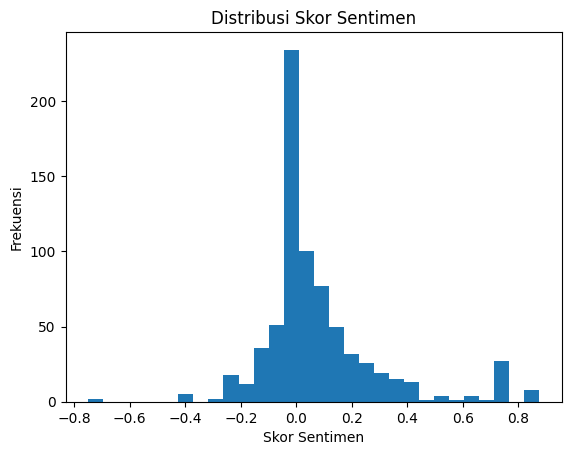

In [62]:
# membuat grafik score untuk memperkirakan klasifikasi supaya lebih akurat
plt.Figure(figsize=(16,8))
plt.hist(df['score'], bins=30)
plt.xlabel("Skor Sentimen")
plt.ylabel("Frekuensi")
plt.title("Distribusi Skor Sentimen")
plt.show()

<h3>Ekstrasi fitur TFIDF
<hr>

In [98]:
df['text_join'] = df['textTranslated'].apply(lambda x: ' '.join(preprocessing(x))) # mengubah list dalam kolom reveiew menjadi string

tfidf = TfidfVectorizer(max_features=2000, min_df=5, max_df=0.85, ngram_range=(1,3))

X_tfidf = tfidf.fit_transform(df['text_join'])
y = df['sentimen']

features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

<h3>Pelatihan model Support Vector Machine (SVM)
<hr>

In [ ]:
# SVM
svm = LinearSVC(C=5)

svm.fit(X_train, y_train)

y_pred_training = svm.predict(X_train)
y_pred_test = svm.predict(X_test)

accuracy_train = accuracy_score(y_pred_training, y_train)
accuracy_test = accuracy_score(y_pred_test, y_test)

print("Akurasi training: ", accuracy_train)
print("Akurasi test: ", accuracy_test)


Akurasi training:  0.9966101694915255
Akurasi test:  0.8918918918918919


<h3>Pelatihan model Random Forest (RF)
<hr>

In [100]:
# RF
rf = RandomForestClassifier(
    max_depth=50,
    min_samples_leaf=5,
    random_state=42
    )

rf.fit(X_train, y_train)

y_pred_training = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

accuracy_train = accuracy_score(y_pred_training, y_train)
accuracy_test = accuracy_score(y_pred_test, y_test)

print("Akurasi training: ", accuracy_train)
print("Akurasi test: ", accuracy_test)


Akurasi training:  0.911864406779661
Akurasi test:  0.9054054054054054


<h3>Ekstrasi fitur Word2Vect
<hr>

In [93]:
sentences = df['processed'].tolist()

w2v = Word2Vec(
    sentences=sentences,
    vector_size=300,
    window=5,
    min_count=5,
    epochs=30
)

def get_sentence_vector(sentence, model):
    vectors = []
    for word in sentence:
        if word in model.wv:
            vectors.append(model.wv[word])
            
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)


X_w2v = np.array([get_sentence_vector(s, w2v) for s in sentences])
y = df['label_rating']

X_train, X_test, y_train, y_test = train_test_split(X_w2v, y, test_size=0.3, random_state=42)

In [94]:
# RF dengan ekstrasi fitur Word2Vect
rf_w2v = RandomForestClassifier(
    max_depth=50,
    min_samples_leaf=5,
    random_state=42
)
rf_w2v.fit(X_train, y_train)

y_pred_training = rf_w2v.predict(X_train)
y_pred_test = rf_w2v.predict(X_test)

accuracy_train = accuracy_score(y_pred_training, y_train)
accuracy_test = accuracy_score(y_pred_test, y_test)

print("Akurasi training: ", accuracy_train)
print("Akurasi test: ", accuracy_test)

Akurasi training:  0.9341085271317829
Akurasi test:  0.8693693693693694


<h3>Testing pada data baru
<hr>

In [101]:
# testing data
data_test = [
    "I recently visited the paris van java mall and I was really impressed by the overall experience, the place is clean, well-organized, and offers a wide variety of shops and restaurants that make it a perfect destination for spending time with family and friends",
    "My experience at paris van java was quite disappointing because it was very crowded, the parking area was difficult to access, and some of the facilities did not meet my expectations which made the visit less enjoyable",
    "The paris van java shopping center is decent and has many popular brands available, but overall it feels just like any other mall and there is nothing particularly unique that makes it stand out",
    "I had an amazing time at paris van java, the ambiance is very relaxing with its semi-outdoor concept, the food options are excellent, and the overall atmosphere makes it one of my favorite places to visit in the city",
    "Although paris van java has a great concept and many entertainment options, I found the prices to be quite expensive and not very budget-friendly for regular visits",
    "Paris van java is a great place to hang out with friends because there are many cafes and entertainment spots, and the open-air concept makes the experience more enjoyable compared to traditional malls",
    "I did not enjoy my visit to paris van java since it was extremely crowded during the weekend and it took a long time just to find a parking spot which was very frustrating",
    "The mall offers a good selection of restaurants and fashion brands, but the layout can be confusing for first-time visitors which makes it slightly inconvenient",
    "I really love the atmosphere at paris van java because it feels more natural and less crowded compared to indoor malls, making it a perfect place to relax and unwind",
    "The facilities at paris van java are quite well maintained, however the prices of food and beverages are relatively high which may not be suitable for everyone",
    "Visiting paris van java was a pleasant experience as the environment is clean, the security is good, and there are many options for shopping and dining",
    "I think paris van java is overrated because even though it looks nice, the overall experience does not match the high expectations people usually have",
    "The semi-outdoor design of paris van java makes it unique and enjoyable, especially in the evening when the atmosphere becomes more lively and comfortable",
    "Unfortunately, my visit to paris van java was not satisfying due to poor parking management and overcrowded areas which made it difficult to move around",
    "Paris van java provides a wide range of entertainment options including cinemas and cafes, making it a suitable place for spending time with family",
    "The place is quite nice and clean, but there is nothing particularly special that makes me want to visit again in the near future",
    "I had a wonderful experience at paris van java, the combination of shopping, dining, and relaxing spaces makes it one of the best malls I have visited",
    "The overall experience at paris van java was average, not too bad but not too impressive either, just a typical shopping center with standard facilities",
    "I was disappointed with the cleanliness in some areas of paris van java, especially in the food court which needs better maintenance",
    "Paris van java is a perfect place for casual hangouts because it offers a comfortable environment, good food options, and a variety of stores to explore"
]

# buat menjadi sebuah dataframe
test_df = pd.DataFrame(data_test, columns=['comment'])

# membuat kolom proses hasil dari preprocessing pada comment dan membalikannya kembali menjadi sebuah string
test_df['proceses'] = test_df['comment'].apply(lambda x: ' '.join(preprocessing(x)))

# transform tfidf
X_test_tfidf = tfidf.transform(test_df['proceses'])

# prediksi svm (tfidf)
preds_svm = svm.predict(X_test_tfidf)

# prediksi rf (tfidf)
preds_rf = rf.predict(X_test_tfidf)

# preprocessing untuk w2v
test_df['processed_list'] = test_df['comment'].apply(preprocessing) # melakukan preprocessing pada comment yang menghasilkan sebuah list
X_test_w2v = np.array([get_sentence_vector(s, w2v) for s in test_df['processed_list']]) # mengubah teks menjadi angka vektor dan mengubahnya lagi menjadi array

# prediksi rf (Word2Vec)
preds_rf_w2v = rf_w2v.predict(X_test_w2v)

# output
for i, (text, svm_pred, rf_pred, rf_w2v_pred) in enumerate(
    zip(test_df['comment'], preds_svm, preds_rf, preds_rf_w2v)
):
    print("Index:", i)
    print("Text:", text)
    print("SVM Prediction     :", svm_pred)
    print("RF TF-IDF Prediction:", rf_pred)
    print("RF W2V Prediction  :", rf_w2v_pred)
    print("------------------------------------------------")

Index: 0
Text: I recently visited the paris van java mall and I was really impressed by the overall experience, the place is clean, well-organized, and offers a wide variety of shops and restaurants that make it a perfect destination for spending time with family and friends
SVM Prediction     : neutral
RF TF-IDF Prediction: neutral
RF W2V Prediction  : positive
------------------------------------------------
Index: 1
Text: My experience at paris van java was quite disappointing because it was very crowded, the parking area was difficult to access, and some of the facilities did not meet my expectations which made the visit less enjoyable
SVM Prediction     : neutral
RF TF-IDF Prediction: neutral
RF W2V Prediction  : positive
------------------------------------------------
Index: 2
Text: The paris van java shopping center is decent and has many popular brands available, but overall it feels just like any other mall and there is nothing particularly unique that makes it stand out
SVM 